# Classification par densité des sites de surveillance du réseau avec PROC MODECLUS

## Résumé exécutif

Un distributeur d'électricité utilise PROC MODECLUS pour trouver des
regroupements non paramétriques fondés sur la densité parmi ses sites de
surveillance du réseau (postes source et capteurs de départ), à partir des
seules coordonnées géographiques. MODECLUS estime une surface de densité sur
les sites et traite les grappes comme des régions de forte densité séparées
par des zones de faible densité. L'exécuter sur 90 sites simulés avec un rayon
de noyau uniforme de 3 km retrouve les trois poches de service denses
intégrées dans les données comme les trois plus grandes grappes (24, 24 et 21
sites), tandis que les sites ruraux dispersés tombent dans des zones creuses et
se scindent en micro-grappes d'un ou deux sites. Cet ensemble de sites isolés
est le livrable opérationnel : une liste de candidats d'actifs distants pour
l'équipe de planification des investissements.

## Sources des données

| Jeu de données | Lignes | Description |
|---------|------|-------------|
| `grid_sites` | 90 | Sites de surveillance électrique synthétiques, générés en ligne avec `call streaminit(70531)` et `rand()`. Trois poches de service denses (CentreUrbain, Banlieue, Industriel) tirées de lois normales bivariées autour de centroïdes distincts, plus 22 sites Ruraux dispersés tirés uniformément sur le territoire. |

| Variable | Type | Description |
|----------|------|-------------|
| `site_id` | Num | Identifiant unique du site de surveillance (1-90). |
| `region` | Car | Étiquette de planification enregistrant comment chaque site a été généré (CentreUrbain, Banlieue, Industriel, Rural) ; exclue de la classification. |
| `x_km`, `y_km` | Num | Position du site en kilomètres sur la grille de planification du distributeur ; les variables de classification. |
| `peak_load_mw` | Num | Pointe de charge annuelle observée (MW) au site ; conservée pour l'interprétation en aval. |

# Classification par densité des sites de surveillance du réseau

Un distributeur d'électricité régional exploite un réseau de **sites de
surveillance** -- postes source et capteurs de départ -- répartis sur son
territoire de desserte. Les planificateurs veulent regrouper ces sites en
**poches de service** naturelles, fondées purement sur la géographie, sans
préciser à l'avance combien de groupes existent, et identifier les **actifs
ruraux isolés** qui n'appartiennent à aucune poche dense.

`PROC MODECLUS` convient bien à cet usage : il effectue une classification
*non paramétrique, fondée sur la densité*. Il estime une fonction de densité
sur les sites, puis traite les grappes comme des régions de forte densité de
sites séparées par des zones de faible densité. Les valeurs aberrantes
dispersées finissent dans leurs propres minuscules grappes plutôt que d'être
absorbées dans une poche -- exactement le comportement recherché pour signaler
les sites distants.

Ce notebook :
1. Génère un réseau de sites synthétique réaliste de 90 sites.
2. Estime la densité des sites avec un **noyau uniforme** et balaie le rayon
   de lissage `R=` pour confirmer que les poches retrouvées sont stables.
3. Fixe un rayon de travail, écrit un jeu de données `OUT=` avec la densité et
   l'étiquette de grappe de chaque site, puis cartographie le résultat.

## Étape 1 -- Générer un réseau de sites de surveillance synthétique

Nous simulons 90 sites. Trois **poches de service** denses sont tirées de
lois normales bivariées autour de centroïdes distincts (CentreUrbain près de
(12, 30), Banlieue près de (30, 15), Industriel près de (20, 42)), donnant des
blocs compacts de forte densité de 24, 24 et 20 sites. Un quatrième groupe de
22 sites **Ruraux** est tiré uniformément sur le territoire, produisant les
sites dispersés et creux qu'un distributeur traiterait comme isolés.

L'étiquette `region` enregistre comment chaque site a été généré ; nous
l'**excluons** délibérément de la classification afin que MODECLUS redécouvre
la structure à partir des seules coordonnées. `peak_load_mw` est conservée
pour l'interprétation ultérieure.

In [1]:
DONNÉES grid_sites;
   APPELER streaminit(70531);
   LONGUEUR region $ 12;

   /* Poche de service urbaine dense */
   FAIRE site_id = 1 JUSQU_À 24;
      region = 'CentreUrbain';
      x_km = 12 + rand('normal') * 1.3;
      y_km = 30 + rand('normal') * 1.3;
      peak_load_mw = 4.5 + rand('normal') * 0.6;
      SORTIE;
   FIN;

   /* Poche de banlieue */
   FAIRE site_id = 25 JUSQU_À 48;
      region = 'Banlieue';
      x_km = 30 + rand('normal') * 1.6;
      y_km = 15 + rand('normal') * 1.6;
      peak_load_mw = 2.8 + rand('normal') * 0.5;
      SORTIE;
   FIN;

   /* Poche industrielle (charge de pointe plus elevee) */
   FAIRE site_id = 49 JUSQU_À 68;
      region = 'Industriel';
      x_km = 20 + rand('normal') * 1.4;
      y_km = 42 + rand('normal') * 1.4;
      peak_load_mw = 6.1 + rand('normal') * 0.8;
      SORTIE;
   FIN;

   /* Sites ruraux disperses (creux, faible charge) */
   FAIRE site_id = 69 JUSQU_À 90;
      region = 'Rural';
      x_km = 2 + rand('uniform') * 46;
      y_km = 2 + rand('uniform') * 50;
      peak_load_mw = 0.8 + rand('uniform') * 1.2;
      SORTIE;
   FIN;
EXÉCUTER;

TITRE "Sites synthétiques de surveillance du réseau";
PROC MEANS data=grid_sites n mean std MIN MAX maxdec=2;
   CLASSE region;
   VAR x_km y_km peak_load_mw;
   ÉTIQUETTE region="Région"
         x_km="Est (km)"
         y_km="Nord (km)"
         peak_load_mw="Pointe de charge (MW)";
EXÉCUTER;

                                      Sites synthétiques de surveillance du réseau                                      

                                                  The MEANS Procedure

                                           Analysis Variable : x_km Est (km)

        Région                N Obs           Mean        Std Dev        Minimum        Maximum
        ---------------------------------------------------------------------------------------
        Banlieue                 24          29.96           1.73          26.51          33.60
        CentreUrbain             24          12.07           1.34           8.65          14.42
        Industriel               20          20.36           0.96          18.52          21.53
        Rural                    22          29.79          10.62          11.06          47.45
        ---------------------------------------------------------------------------------------

                                           Analysis Vari


NOTE: DATA grid_sites


NOTE: Wrote grid_sites (90 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: Option TITLE changed to Sites synthétiques de surveillance du réseau.
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


Les moyennes confirment trois poches compactes et un groupe diffus. Les trois
régions denses ont de faibles écarts-types de coordonnées (environ 1 à 1,7 km
sur chaque axe) autour de centroïdes bien séparés, tandis que le groupe Rural
s'étale sur toute la grille (écarts-types supérieurs à 10 km sur les deux
axes). La pointe de charge distingue aussi les poches -- les sites Industriel
affichent en moyenne environ 6 MW, CentreUrbain environ 4,6 MW, Banlieue
environ 2,7 MW, et les sites Ruraux environ 1,5 MW -- un contexte utile une
fois les grappes géographiques en main.

## Étape 2 -- Classification par densité à noyau uniforme et balayage du rayon

L'estimation de densité à noyau uniforme utilise un **rayon `R=`** : chaque
site situé à moins de `R` kilomètres contribue à la densité locale d'un site.
Un petit `R` donne une densité chahutée qui fragmente le territoire ; un grand
`R` sur-lisse et fusionne les poches. Un expert SAS ne se fie jamais à une
seule valeur -- il balaie une plage de rayons et cherche un nombre de grappes
qui soit **stable**, où les poches denses persistent tandis que seul le
nombre de singletons dispersés dérive.

Ici, `M=1` sélectionne la méthode de classification 1 (la méthode non
paramétrique standard), et nous demandons les rayons `R=2.5 to 4 by 0.5` en un
seul appel. MODECLUS exécute l'analyse une fois par rayon et rapporte le
nombre de grappes pour chacun. `SHORT` supprime les statistiques détaillées
par grappe.

In [2]:
TITRE "Classification par densité à noyau uniforme des sites du réseau";
title2 "Balayage du rayon R = 2.5 à 4.0 km";

PROC MODECLUS data=grid_sites m=1 r=2.5 JUSQU_À 4 PAR 0.5 short;
   VAR x_km y_km;
   id site_id;
EXÉCUTER;

                            Classification par densité à noyau uniforme des sites du réseau                             
                                           Balayage du rayon R = 2.5 à 4.0 km                                           


                                                 The MODECLUS Procedure                                                 

  Method: 1
  Number of Observations: 90
  Number of Variables: 2
  Variables: x_km y_km

  Density Estimation: Bandwidth=2.5000
  Number of Clusters: 23

  Density Estimation: Bandwidth=3.0000
  Number of Clusters: 22

  Density Estimation: Bandwidth=3.5000
  Number of Clusters: 19

  Density Estimation: Bandwidth=4.0000
  Number of Clusters: 18





NOTE: Option TITLE changed to Classification par densité à noyau uniforme des sites du réseau.
NOTE: Option TITLE2 changed to Balayage du rayon R = 2.5 à 4.0 km.
NOTE: PROC MODECLUS data=grid_sites method=1

NOTE: Using Python/scipy for density-based clustering
NOTE: Density estimation: 23 Cluster(s) found. Bandwidth=2.5000 Mode-based Clustering complete.
NOTE: Density estimation: 22 Cluster(s) found. Bandwidth=3.0000 Mode-based Clustering complete.
NOTE: Density estimation: 19 Cluster(s) found. Bandwidth=3.5000 Mode-based Clustering complete.
NOTE: Density estimation: 18 Cluster(s) found. Bandwidth=4.0000 Mode-based Clustering complete.
NOTE: PROC MODECLUS: 90 observations, 2 variables, method=1


Le nombre de grappes évolue seulement en douceur sur le balayage -- 23
grappes à `R=2,5`, 22 à `R=3,0`, 19 à `R=3,5`, et 18 à `R=4,0`. Les
décomptes bruts élevés proviennent des sites ruraux dispersés : chaque site
isolé se trouve dans son propre voisinage creux et forme une grappe d'un seul
site, si bien que la plupart des 18-23 « grappes » sont des singletons. Ce
qui reste constant en profondeur, c'est la structure qui compte -- les trois
poches denses demeurent trois grandes grappes bien séparées à chaque rayon.
À mesure que `R` s'élargit, quelques singletons dispersés fusionnent avec un
voisin ou une poche proche, ce qui explique pourquoi le décompte total dérive
lentement vers le bas plutôt que d'osciller violemment. Cette stabilité est
le signal que la solution à trois poches est réelle et non un artefact d'une
seule largeur de bande.

## Étape 3 -- Solution de classification finale pour la cartographie

Ayant constaté que les trois poches sont stables sur tout le balayage, nous
fixons un rayon de travail unique (`R=3` km) et demandons l'option **ALL**
pour l'affichage complet par grappe, plus **OUT=** pour écrire les
coordonnées d'origine avec l'estimation de `DENSITY` et l'affectation de
`CLUSTER`, afin de pouvoir cartographier le résultat. Les grappes sont
numérotées par densité de mode décroissante, si bien que les poches les plus
denses sont les grappes 1, 2 et 3, et les sites creux prennent les numéros
supérieurs.

In [3]:
TITRE "Solution finale de classification par densité";
title2 "Noyau uniforme, R = 3 km";

PROC MODECLUS data=grid_sites m=1 r=3 out=join_out all;
   VAR x_km y_km;
   id site_id;
EXÉCUTER;

                                     Solution finale de classification par densité                                      
                                                Noyau uniforme, R = 3 km                                                


                                                 The MODECLUS Procedure                                                 

  Method: 1
  Number of Observations: 90
  Number of Variables: 2
  Variables: x_km y_km

  Density Estimation: Bandwidth=3.0000
  Number of Clusters: 22

  Cluster Summary
  ---------------------------------------------------------------
  Cluster   N   Mode   Mode Density
  ---------------------------------------------------------------
        1   24           5      0.009038
        2   24          46      0.007860
        3   21          56      0.007860
        4    3          83      0.001179
        5    1          29      0.000393
        6    1          69      0.000393
        7    1          70      0.000393
      


NOTE: Option TITLE changed to Solution finale de classification par densité.
NOTE: Option TITLE2 changed to Noyau uniforme, R = 3 km.
NOTE: PROC MODECLUS data=grid_sites method=1

NOTE: Using Python/scipy for density-based clustering
NOTE: Density estimation: 22 Cluster(s) found. Bandwidth=3.0000 Mode-based Clustering complete.
NOTE: PROC MODECLUS: 90 observations, 2 variables, method=1


Le récapitulatif des grappes rend la structure explicite. La solution
`R=3` renvoie **22 grappes**, mais elles se répartissent nettement par
niveaux de densité :

- **Grappe 1** -- 24 sites, densité de mode d'environ 0,0090 (la poche
  CentreUrbain).
- **Grappe 2** -- 24 sites, densité de mode d'environ 0,0079 (la poche
  Banlieue).
- **Grappe 3** -- 21 sites, densité de mode d'environ 0,0079 (la poche
  Industriel ; elle récupère un site rural tombé par hasard sur son bord).
- **Grappes 4-22** -- un groupe de trois sites et dix-huit grappes d'un seul
  site, toutes à une densité de mode d'environ 0,0004, à peu près vingt fois
  plus creuses que les poches.

Les trois poches denses représentent 69 des 90 sites ; les 21 sites restants
sont les actifs ruraux dispersés, chacun se trouvant seul ou presque seul dans
un voisinage de faible densité. C'est la densité, et non un nombre de grappes
préétabli, qui trace la frontière entre une poche de service et un site
isolé.

## Étape 4 -- Cartographier les grappes

Nous marquons chaque site selon qu'il est tombé dans l'une des trois poches
denses (`cluster <= 3`) ou dans une micro-grappe creuse, puis traçons chaque
site à ses coordonnées cartographiques, coloré selon ce statut. C'est la vue
du planificateur : les poches denses à gérer comme des territoires de
service, et les sites isolés à signaler pour un traitement séparé.

                                      Poches de service et sites isolés retrouvés                                       
                                 Classification par densité à noyau uniforme, R = 3 km                                  




NOTE: DATA mapped


NOTE: Read 90 rows from join_out.
NOTE: Wrote mapped (90 rows, 10 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: Option TITLE changed to Poches de service et sites isolés retrouvés.
NOTE: Option TITLE2 changed to Classification par densité à noyau uniforme, R = 3 km.
NOTE: PROC SGPLOT data=mapped

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


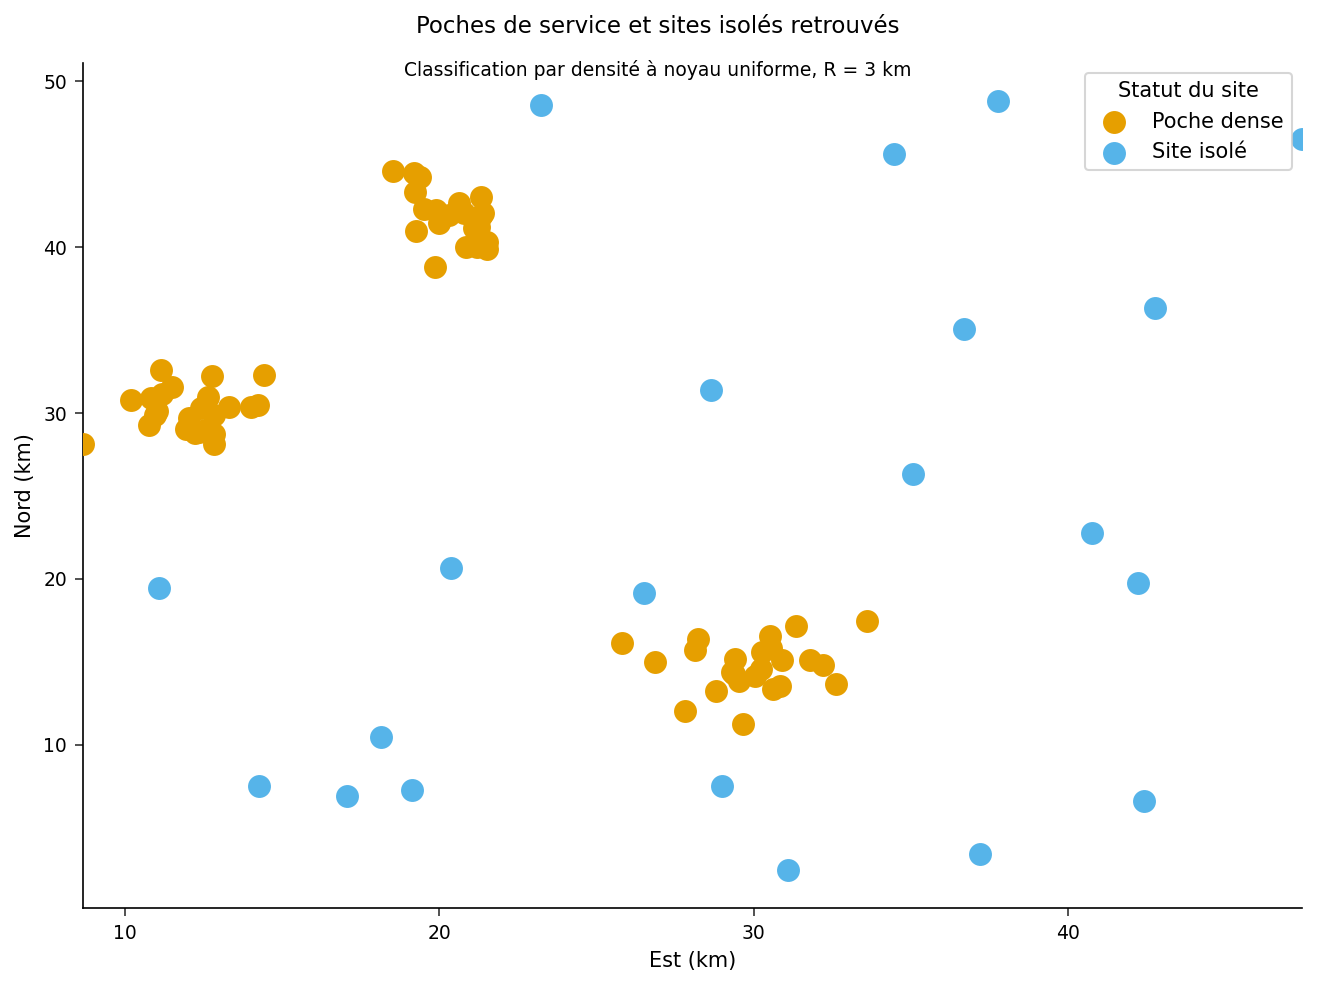

In [4]:
DONNÉES mapped;
   DÉFINIR join_out;
   LONGUEUR status $ 16;
   SI cluster <= 3 ALORS status = 'Poche dense';
   SINON status = 'Site isolé';
EXÉCUTER;

TITRE "Poches de service et sites isolés retrouvés";
title2 "Classification par densité à noyau uniforme, R = 3 km";
PROC SGPLOT data=mapped;
   SCATTER x=x_km y=y_km / GROUPE=status markerchar=cluster
                           MARKERATTRS=(size=10);
   XAXIS ÉTIQUETTE="Est (km)";
   YAXIS ÉTIQUETTE="Nord (km)";
   keylegend / TITRE="Statut du site";
EXÉCUTER;

TITRE;

## Interprétation des résultats

**Ce que MODECLUS a trouvé.** Piloté uniquement par `(x_km, y_km)`, la
procédure retrouve les trois poches de service denses intégrées dans les
données -- les blocs CentreUrbain, Banlieue et Industriel -- comme les trois
plus grandes grappes, les plus denses (24, 24 et 21 sites). Les sites ruraux
dispersés, tirés uniformément sur le territoire, tombent dans des zones
creuses et se scindent en grappes d'un ou deux sites plutôt que d'être
absorbés dans une poche. Sur la carte, ce sont les points séparés des trois
blocs compacts. Cet ensemble isolé est le livrable opérationnel : une liste
de candidats d'actifs distants pour l'équipe de planification des
investissements.

**Pourquoi le balayage de lissage importe.** Aucun `R` unique ne fait
autorité pour une classification non paramétrique par densité. Balayer
`R=2.5 to 4 by 0.5` permet de confirmer que les poches sont *stables* à
travers les niveaux de lissage plutôt qu'un artefact d'une seule largeur de
bande. Sur tout le balayage, le nombre de grappes ne bouge que de 23 à 18, et
le changement porte entièrement sur le nombre de singletons dispersés -- les
trois poches denses persistent tout du long. Là où la structure est restée
stable ainsi, nous avons une solution défendable ; si le décompte avait
oscillé violemment, la structure serait fragile et ne devrait pas guider les
décisions d'investissement.

**La densité hiérarchise le résultat.** Comme les grappes sont numérotées par
densité de mode décroissante, la séparation entre poches et sites isolés est
quantitative, non arbitraire : les trois poches se situent près d'une densité
de mode de 0,008-0,009 tandis que chaque site isolé se situe près de 0,0004,
environ vingt fois plus creux. Un planificateur peut fixer un seuil de
densité et lire les actifs isolés directement dans les colonnes `CLUSTER` et
`DENSITY` de `join_out`.

**Usage pratique.** Le jeu de données `join_out` donne à chaque site une
densité et une étiquette de grappe qui peuvent alimenter le travail en aval --
dimensionner les équipes et les pièces de rechange par poche de service,
planifier les tournées d'inspection, ou prioriser le renforcement du réseau
dans la grappe industrielle dense (le `peak_load_mw` le plus élevé, environ 6
MW), tout en programmant les sites ruraux isolés pour une maintenance séparée
et moins fréquente.

*Note sur les données synthétiques :* les coordonnées et les charges sont
simulées avec une graine fixe (`call streaminit(70531)`) si bien que le
notebook est entièrement reproductible hors ligne ; sur des données réelles
d'un distributeur, on substituerait des coordonnées de sites relevées et des
charges de pointe mesurées. Les décomptes exacts de grappes dépendent du
tirage aléatoire et du rayon choisi.